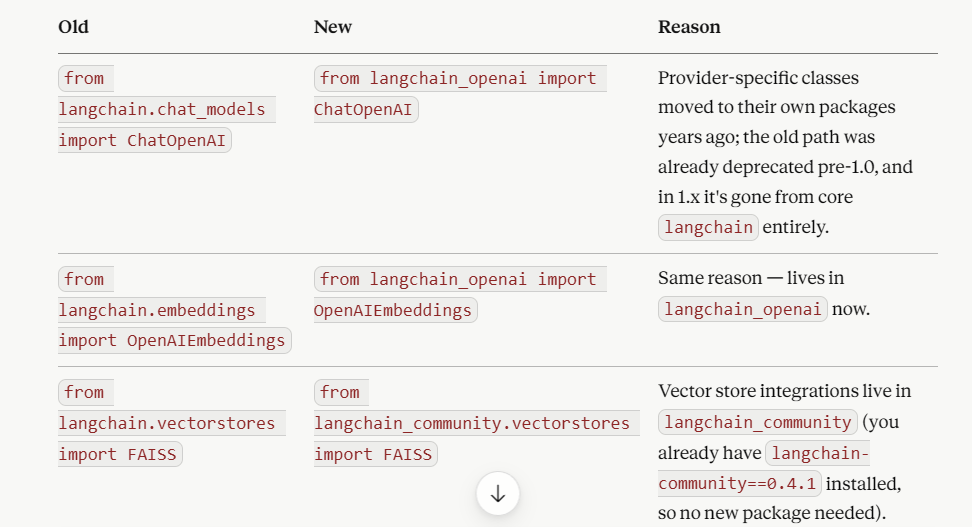

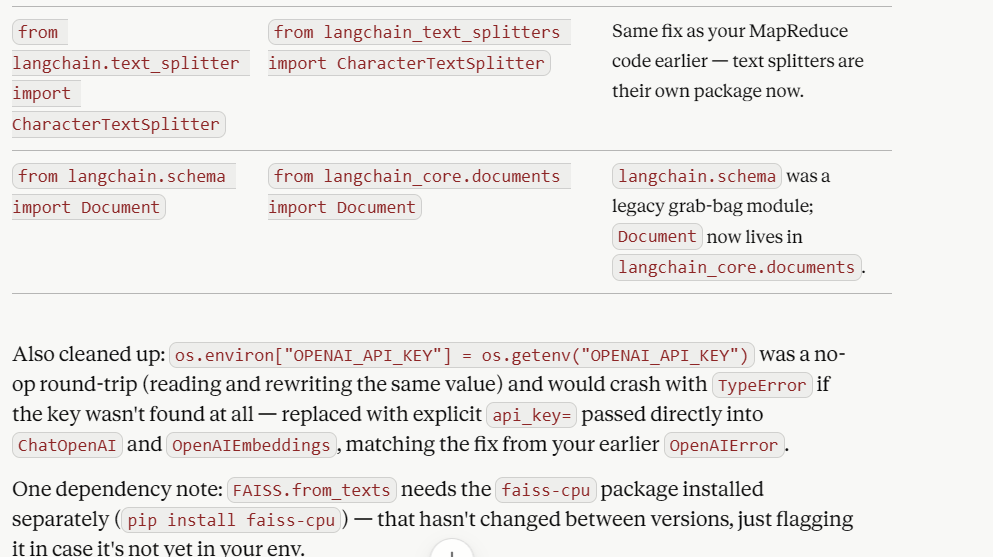

In [1]:
# ✅ Step 1: Imports
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import CharacterTextSplitter
from langchain_core.documents import Document
from dotenv import load_dotenv
import os

# ✅ Step 2: Load API key
load_dotenv(dotenv_path="env")
openai_api_key = "openai_api_key"

# ✅ Step 3: Setup LLM and Embeddings
llm = ChatOpenAI(temperature=0, model="gpt-4o-mini", api_key=openai_api_key)
embedding = OpenAIEmbeddings(api_key=openai_api_key)

# ✅ Step 4: Load and split document
with open("sample.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

splitter = CharacterTextSplitter(separator="\n", chunk_size=300, chunk_overlap=50)
texts = splitter.split_text(raw_text)
documents = [Document(page_content=t) for t in texts]

# ✅ Step 5: Vector Store (optional for Retriever chains)
vectorstore = FAISS.from_texts(texts, embedding)
retriever = vectorstore.as_retriever()

print("✅ Base setup complete.")

C:\Users\KAVITHA\AppData\Local\Temp\ipykernel_12800\221318946.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


✅ Base setup complete.


In [2]:
from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_template(
    "Use the following context to answer the question:\n\n{context}\n\nQuestion: {question}"
)

stuff_chain = create_stuff_documents_chain(
    llm,
    prompt,
    document_variable_name="context"
)

response = stuff_chain.invoke({
    "context": documents[:3],
    "question": "What is this document about?"
})

print("\n📌 StuffDocumentsChain Answer:", response)


📌 StuffDocumentsChain Answer: This document is about LangChain, a framework designed for building applications that utilize large language models (LLMs). It provides information on its creator, Harrison Chase, and highlights the features and common use cases of LangChain, such as supporting retrieval-augmented generation (RAG), agents, memory, tools, and its applications in chatbots, document question-and-answer systems, and AI workflows.


In [3]:
# Initial prompt to summarize the first chunk
# Use case: Starts with a base answer and refines it using subsequent documents — good when each chunk contributes incrementally.

from langchain_core.prompts import PromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser

initial_prompt = PromptTemplate.from_template("""
Write a concise summary of the following text:

{context}
""")

# Refine prompt to update the previous summary with new context
refine_prompt = PromptTemplate.from_template("""
We have an existing summary:
"{existing_answer}"

Refine the summary with this new context:
"{context}"

If the context isn't useful, return the original summary.
""")

# Set up individual chains
initial_summary_chain = initial_prompt | llm | StrOutputParser()
refine_summary_chain = refine_prompt | llm | StrOutputParser()

# Start with first chunk
summary = initial_summary_chain.invoke({"context": documents[0].page_content})

# Iteratively refine with remaining docs
for doc in documents[1:]:
    summary = refine_summary_chain.invoke({
        "existing_answer": summary,
        "context": doc.page_content
    })

# Output final summary
print("📄 Refined Summary:\n")
print(summary)

📄 Refined Summary:

LangChain is a framework developed by Harrison Chase for building applications using large language models (LLMs). It supports various features such as retrieval-augmented generation (RAG), agents, memory, and tools, and is commonly utilized in chatbots, document Q&A, and AI workflows.
